# 1. Estructura del panel

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PASO 1: Inspeccionar unicamente el nombre de las columnas para corroborar el diccionario

In [30]:
df_preview = pd.read_stata('MSP_hospitales.dta', iterator=True)
all_columns = df_preview.variable_labels()
column_names_only = list(all_columns.keys())# Solo el nombre (no el key / descripcion)

print(f"Total de columnas: {len(all_columns)}")
print("\nNombres: ")
print(column_names_only)

Total de columnas: 240

Nombres: 
['date', 'ruc', 'employer_id', 'decentralized_entity_merge', 'eod_code', 'health_center_name', 'care_level', 'service_class', 'province_code_alt', 'province_name_alt', 'canton_code1', 'canton_name1', 'parish_code', 'parish_sri', 'parish_name', 'longitude', 'latitude', 'dostay_mean', 'age_mean', 'hospital_discharges', 'deaths_total', 'deaths_over48h', 'deaths_under48h', 'mortality_rate', 'mortality_rate_over48h', 'mortality_rate_under48h', 'medical_visits_firstlevel', 'encoded51_bymonth', 'payment51_bymonth', 'accrued51_bymonth', 'inicial51_', 'encoded53_bymonth', 'payment53_bymonth', 'accrued53_bymonth', 'inicial53_', 'encoded57_bymonth', 'payment57_bymonth', 'accrued57_bymonth', 'inicial57_', 'encoded58_bymonth', 'payment58_bymonth', 'accrued58_bymonth', 'inicial58_', 'encoded71_bymonth', 'payment71_bymonth', 'accrued71_bymonth', 'inicial71_', 'encoded73_bymonth', 'payment73_bymonth', 'accrued73_bymonth', 'inicial73_', 'encoded75_bymonth', 'payment75_

PASO 2: Extraer columnas especificas (identificadas como prioritarias)

In [31]:

identificadores = [
    'date',
    'health_center_name',
    'care_level',
    'province_name_alt',
    'canton_name1'
]

salud = [
    'hospital_discharges',
    'deaths_total',
    'mortality_rate',
    'medical_visits_firstlevel',
    'prevent_consult_first',
    'morb_consult_first'
]

finanzas = [
    'payment51_bymonth',
    'payment53_bymonth',
    'pagado_medic_',
    'pagado_medsupp_',
    'codificado_monthly',
    'devengado_monthly',
    'pagado_monthly',
    'cod_medic_',
    'cod_medsupp_'
]

recursos_humanos = [
    'gender_1',
    'gender_2',
    'doctors',
    'spec_doctors',
    'nurses'
]

columns_to_extract = (identificadores + salud + finanzas + recursos_humanos)

df = pd.read_stata('MSP_hospitales.dta', columns=columns_to_extract)

PASO 3: Estructura de la base

In [32]:

print("="*80)
print("ESTRUCTURA - Resumen")
print("="*80)

print(f"\nTotal de observaciones (filas): {len(df)}")
print(f"Variables totales (columnas): {len(df.columns)}")

# Num de hospitales unicos
n_hospitals = df['health_center_name'].nunique()
print(f"\nHospitales únicos: {n_hospitals}")


# Rango de fechas
df['date'] = pd.to_datetime(df['date'])
print(f"\nRango de fechas: {df['date'].min()} to {df['date'].max()}")
print(f"Total de meses en el conjunto de datos: {df['date'].nunique()}")


# Desde 2015 al 2023, una observación por mes
# ¿Cuantas observaciones deberian haber, dado el num de hospitales?

expected_obs = n_hospitals * df['date'].nunique()
print(f"\nObservaciones esperadas (si está equilibrado): {expected_obs}")
print(f"Observaciones reales: {len(df)}")
print(f"Observaciones faltantes: {expected_obs - len(df)}")
print(f"Integridad del panel: {(len(df) / expected_obs * 100):.1f}%")


# Que hospitales estan completos?

print("\n" + "="*80)
print("OBSERVACIONES POR HOSPITAL")
print("="*80)
obs_per_hospital = df.groupby('health_center_name').size()
print(obs_per_hospital.describe())
print(f"\nHospitales con datos completos: {(obs_per_hospital == obs_per_hospital.max()).sum()}")
print(f"Hospitales con datos incompletos: {(obs_per_hospital < obs_per_hospital.max()).sum()}")

duplicates = df.groupby(['health_center_name', 'date']).size()
duplicates = duplicates[duplicates > 1]
if len(duplicates) > 0:
    print(f"\nADVERTENCIA: Encontrado {len(duplicates)} ¡Duplicados de fechas de hospitalización!")
else:
    print("\n✓ No se encontraron duplicados")

ESTRUCTURA - Resumen

Total de observaciones (filas): 12374
Variables totales (columnas): 25

Hospitales únicos: 121

Rango de fechas: 2015-01-01 00:00:00 to 2023-12-01 00:00:00
Total de meses en el conjunto de datos: 108

Observaciones esperadas (si está equilibrado): 13068
Observaciones reales: 12374
Observaciones faltantes: 694
Integridad del panel: 94.7%

OBSERVACIONES POR HOSPITAL
count    121.000000
mean     102.264463
std       15.776971
min       12.000000
25%      108.000000
50%      108.000000
75%      108.000000
max      108.000000
dtype: float64

Hospitales con datos completos: 95
Hospitales con datos incompletos: 26

✓ No se encontraron duplicados


PASO 4: Ver que información está faltante 
(cuantos y que hospitales estan incompletos)

In [33]:


obs_per_hospital = df.groupby('health_center_name').size()
max_obs = obs_per_hospital.max()
incomplete_hospitals = obs_per_hospital[obs_per_hospital < max_obs].index.tolist()

print(f"{len(incomplete_hospitals)} hospitales con datos incompletos\n")
print("="*80)

# For each incomplete hospital, show which months they have data for
for hospital in incomplete_hospitals[:10]:  # Show first 10 to avoid too much output
    hospital_data = df[df['health_center_name'] == hospital]['date'].sort_values()
    
    print(f"\n{hospital}")
    print(f"  Total de meses: {len(hospital_data)} (faltando {max_obs - len(hospital_data)})")
    print(f"  Rango de fechas: {hospital_data.min()} a {hospital_data.max()}")
    
    # Check if missing at beginning, end, or middle
    all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='MS')
    missing_dates = set(all_dates) - set(hospital_data)
    
    if len(missing_dates) > 0:
        missing_sorted = sorted(list(missing_dates))
        if len(missing_sorted) <= 5:
            print(f"  Fechas faltantes: {[d.strftime('%Y-%m') for d in missing_sorted]}")
        else:
            print(f"  Fechas faltantes: {missing_sorted[0].strftime('%Y-%m')} a {missing_sorted[-1].strftime('%Y-%m')} ({len(missing_sorted)} meses)")

print("\n" + "etc ...")


26 hospitales con datos incompletos


CENTRO AMBULATORIO INTENSIVO
  Total de meses: 12 (faltando 96)
  Rango de fechas: 2023-01-01 00:00:00 a 2023-12-01 00:00:00
  Fechas faltantes: 2015-01 a 2022-12 (96 meses)

CENTRO DE SALUD N. 4
  Total de meses: 41 (faltando 67)
  Rango de fechas: 2015-01-01 00:00:00 a 2018-05-01 00:00:00
  Fechas faltantes: 2018-06 a 2023-12 (67 meses)

CENTRO ESPECIALIZADO EN TRATAMIENTO A PERSONAS CON CONSUMO PROBLEMATICO DE ALCOHOL Y OTRAS DROGAS (CETAD) - ESMERALDAS
  Total de meses: 97 (faltando 11)
  Rango de fechas: 2015-01-01 00:00:00 a 2023-12-01 00:00:00
  Fechas faltantes: 2016-02 a 2016-12 (11 meses)

HOSPITAL BASICO DE ATUNTAQUI
  Total de meses: 107 (faltando 1)
  Rango de fechas: 2015-01-01 00:00:00 a 2023-12-01 00:00:00
  Fechas faltantes: ['2019-06']

HOSPITAL BASICO DE BANOS
  Total de meses: 72 (faltando 36)
  Rango de fechas: 2016-01-01 00:00:00 a 2021-12-01 00:00:00
  Fechas faltantes: 2015-01 a 2023-12 (36 meses)

HOSPITAL BASICO DE COTACAC

# Lineas de tendencia generales

In [34]:
# Crear panel balanceado (solo hospitales con datos completos)
obs_per_hospital = df.groupby('health_center_name').size()
max_obs = obs_per_hospital.max()
complete_hospitals = obs_per_hospital[obs_per_hospital == max_obs].index.tolist()

df_balanced = df[df['health_center_name'].isin(complete_hospitals)].copy()


print(f"Panel balanceado: {len(df_balanced)} observaciones, {df_balanced['health_center_name'].nunique()} hospitales")

Panel balanceado: 10260 observaciones, 95 hospitales


1. TENDENCIA DE LA TASA DE MORTALIDAD (GENERAL)

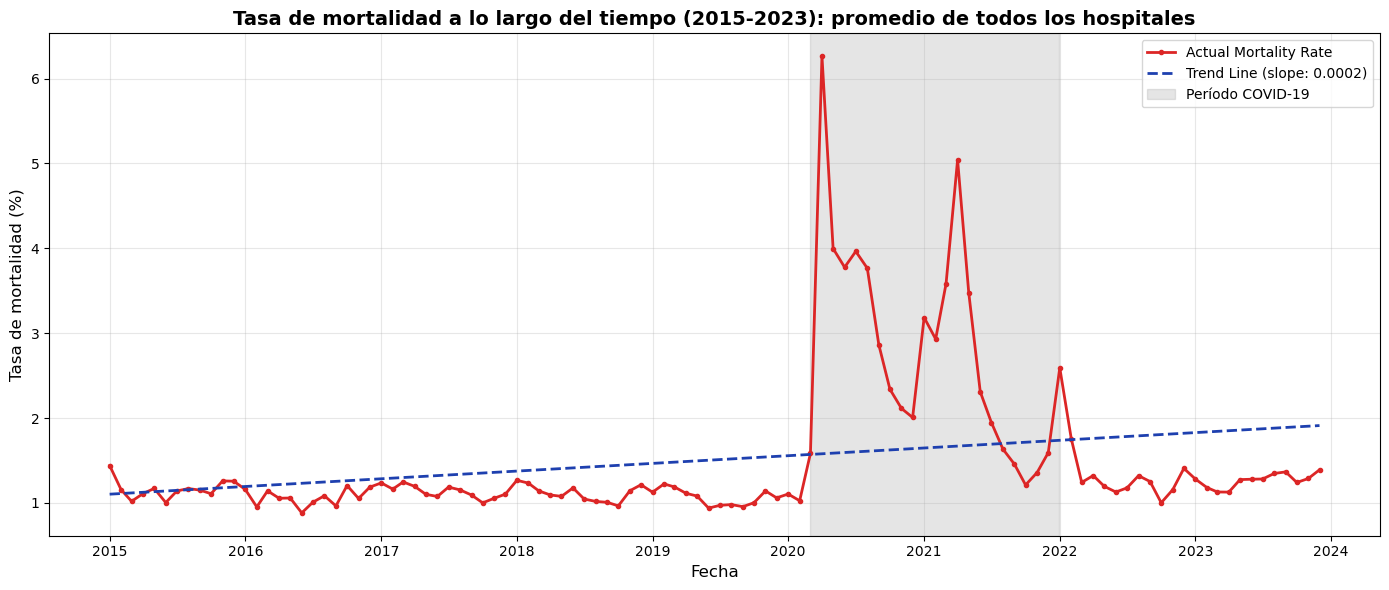

ANÁLISIS DE TENDENCIAS DE MORTALIDAD
Pendiente de tendencia: 0.000248 (por día)
Dirección de la tendencia: CRECIENTE

Media general: 1.507%


In [35]:
# Tasa de mortalidad promedio por mes (en todos los hospitales)
mortality_over_time = df_balanced.groupby('date')['mortality_rate'].mean().reset_index()

# Fecha numérica
mortality_over_time['date_numeric'] = (mortality_over_time['date'] - mortality_over_time['date'].min()).dt.days

# Línea de tendencia
z = np.polyfit(mortality_over_time['date_numeric'], mortality_over_time['mortality_rate'], 1)
p = np.poly1d(z)
trend_line = p(mortality_over_time['date_numeric'])

# Create the plot
plt.figure(figsize=(14, 6))
plt.plot(mortality_over_time['date'], mortality_over_time['mortality_rate'], 
         linewidth=2, color='#dc2626', marker='o', markersize=3, label='Actual Mortality Rate')

# Add trend line
plt.plot(mortality_over_time['date'], trend_line, 
         linewidth=2, color='#1e40af', linestyle='--', label=f'Trend Line (slope: {z[0]:.4f})')

plt.title('Tasa de mortalidad a lo largo del tiempo (2015-2023): promedio de todos los hospitales', 
          fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Tasa de mortalidad (%)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add COVID period shading
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
            alpha=0.2, color='gray', label='Período COVID-19')

plt.legend()
plt.tight_layout()
plt.show()

# Estadística
print("="*80)
print("ANÁLISIS DE TENDENCIAS DE MORTALIDAD")
print("="*80)
print(f"Pendiente de tendencia: {z[0]:.6f} (por día)")
print(f"Dirección de la tendencia: {'CRECIENTE' if z[0] > 0 else 'DECRECIENTE'}")
print(f"\nMedia general: {df_balanced['mortality_rate'].mean():.3f}%")

2. TENDENCIA DE ALTAS HOSPITALARIAS (GENERAL)

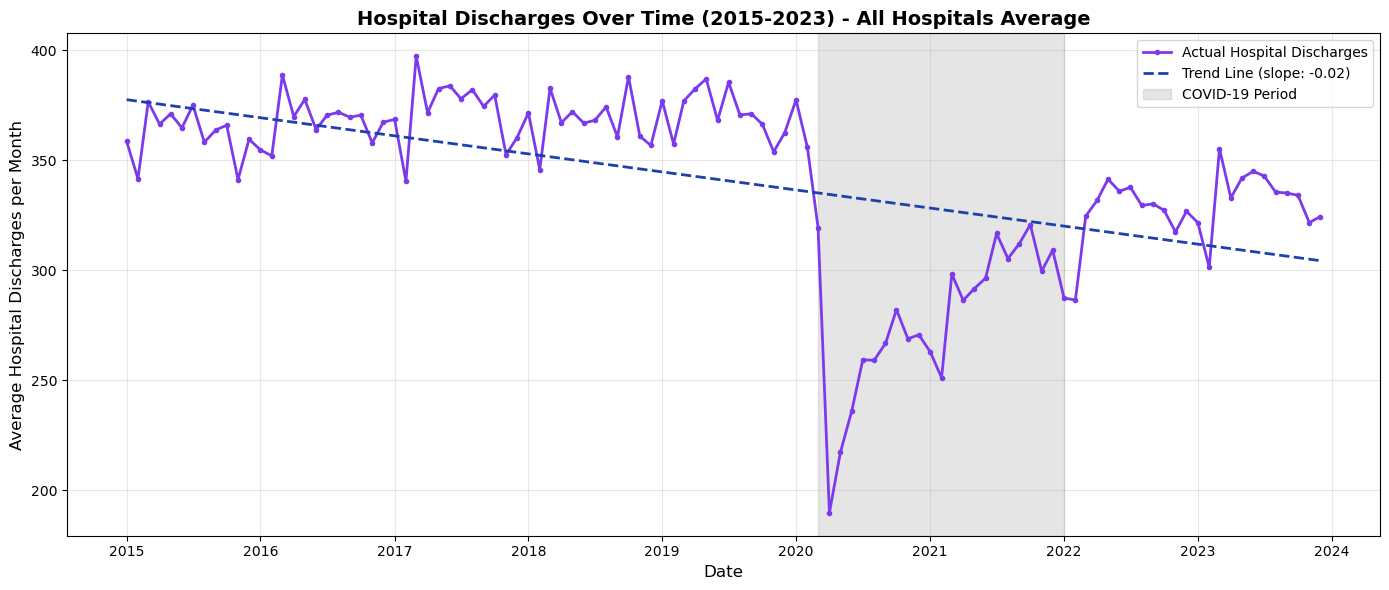

ANÁLISIS DE TENDENCIAS DE INGRESOS HOSPITALARIOS
Trend slope: -0.0225 discharges per day
Trend direction: DECREASING

Overall mean: 340.96 discharges/month

Pre-COVID: 368.31
During COVID: 278.20
Post-COVID: 327.84


In [36]:

discharges_over_time = df_balanced.groupby('date')['hospital_discharges'].mean().reset_index()


discharges_over_time['date_numeric'] = (discharges_over_time['date'] - discharges_over_time['date'].min()).dt.days


z = np.polyfit(discharges_over_time['date_numeric'], discharges_over_time['hospital_discharges'], 1)
p = np.poly1d(z)
trend_line = p(discharges_over_time['date_numeric'])

# Create the plot
plt.figure(figsize=(14, 6))
plt.plot(discharges_over_time['date'], discharges_over_time['hospital_discharges'], 
         linewidth=2, color='#7c3aed', marker='o', markersize=3, label='Actual Hospital Discharges')

# Add trend line
plt.plot(discharges_over_time['date'], trend_line, 
         linewidth=2, color='#1e40af', linestyle='--', label=f'Trend Line (slope: {z[0]:.2f})')

plt.title('Hospital Discharges Over Time (2015-2023) - All Hospitals Average', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Hospital Discharges per Month', fontsize=12)
plt.grid(True, alpha=0.3)

# Add COVID period shading
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
            alpha=0.2, color='gray', label='COVID-19 Period')

plt.legend()
plt.tight_layout()
plt.show()

# Statistics
print("="*80)
print("ANÁLISIS DE TENDENCIAS DE INGRESOS HOSPITALARIOS")
print("="*80)
print(f"Trend slope: {z[0]:.4f} discharges per day")
print(f"Trend direction: {'INCREASING' if z[0] > 0 else 'DECREASING'}")
print(f"\nOverall mean: {df_balanced['hospital_discharges'].mean():.2f} discharges/month")
print(f"\nPre-COVID: {df_balanced[df_balanced['date'] < '2020-03-01']['hospital_discharges'].mean():.2f}")
print(f"During COVID: {df_balanced[(df_balanced['date'] >= '2020-03-01') & (df_balanced['date'] <= '2021-12-31')]['hospital_discharges'].mean():.2f}")
print(f"Post-COVID: {df_balanced[df_balanced['date'] > '2021-12-31']['hospital_discharges'].mean():.2f}")

3. TENDENCIA DEL GASTO (GENERAL)

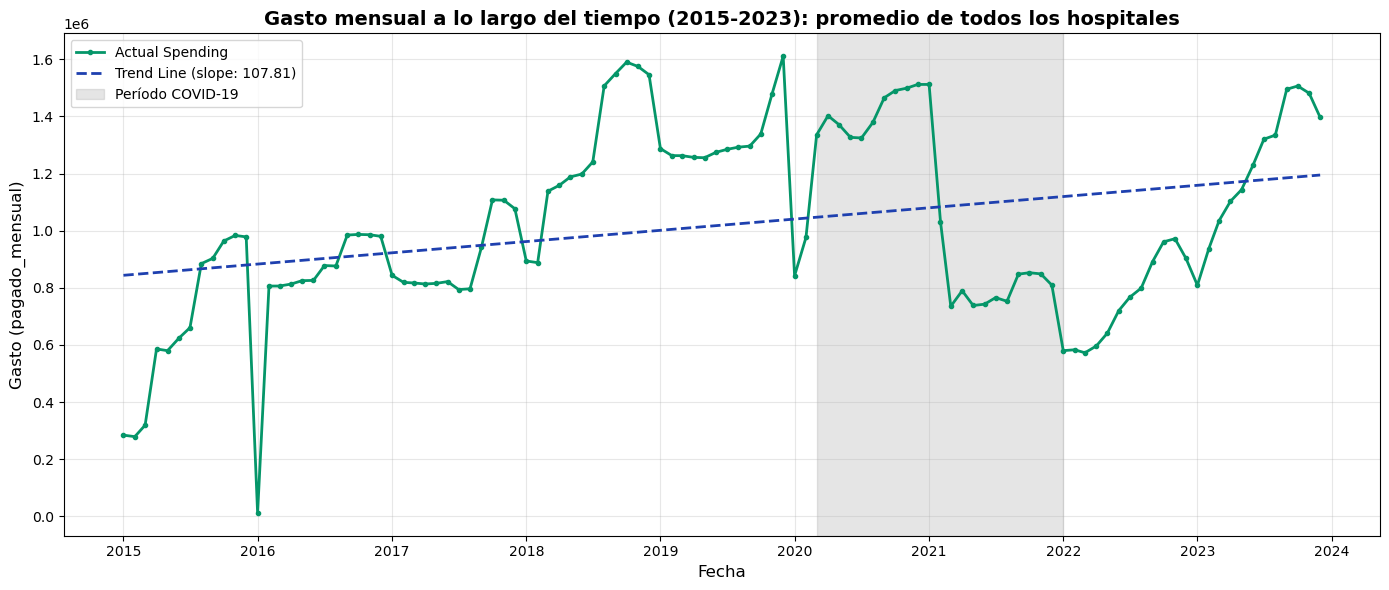

ANÁLISIS DE TENDENCIAS DE GASTO
Pendiente de tendencia: 107.81 (por día)
Dirección de la tendencia: CRECIENTE

Media general: $5,837,150.54

Pre-COVID: $5,505,996.69
During COVID: $6,324,811.67
Post-COVID: $6,245,608.60


In [41]:
# Gasto promedio por mes (en todos los hospitales)
spending_over_time = df_balanced.groupby('date')['cod_medsupp_'].mean().reset_index()

# Fecha numerica 
spending_over_time['date_numeric'] = (spending_over_time['date'] - spending_over_time['date'].min()).dt.days

# Linea de tendencia
z = np.polyfit(spending_over_time['date_numeric'], spending_over_time['cod_medsupp_'], 1)
p = np.poly1d(z)
trend_line = p(spending_over_time['date_numeric'])

# Create the plot
plt.figure(figsize=(14, 6))
plt.plot(spending_over_time['date'], spending_over_time['cod_medsupp_'], 
         linewidth=2, color='#059669', marker='o', markersize=3, label='Actual Spending')

# Add trend line
plt.plot(spending_over_time['date'], trend_line, 
         linewidth=2, color='#1e40af', linestyle='--', label=f'Trend Line (slope: {z[0]:.2f})')

plt.title('Gasto mensual a lo largo del tiempo (2015-2023): promedio de todos los hospitales', 
          fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Gasto (pagado_mensual)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add COVID period shading
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
            alpha=0.2, color='gray', label='Período COVID-19')

plt.legend()
plt.tight_layout()
plt.show()

# Statistics
print("="*80)
print("ANÁLISIS DE TENDENCIAS DE GASTO")
print("="*80)
print(f"Pendiente de tendencia: {z[0]:.2f} (por día)")
print(f"Dirección de la tendencia: {'CRECIENTE' if z[0] > 0 else 'DECRECIENTE'}")
print(f"\nMedia general: ${df_balanced['pagado_monthly'].mean():,.2f}")
print(f"\nPre-COVID: ${df_balanced[df_balanced['date'] < '2020-03-01']['pagado_monthly'].mean():,.2f}")
print(f"During COVID: ${df_balanced[(df_balanced['date'] >= '2020-03-01') & (df_balanced['date'] <= '2021-12-31')]['pagado_monthly'].mean():,.2f}")
print(f"Post-COVID: ${df_balanced[df_balanced['date'] > '2021-12-31']['pagado_monthly'].mean():,.2f}")

4. TENDENCIA DE FUERZA LABORAL (GENERAL)

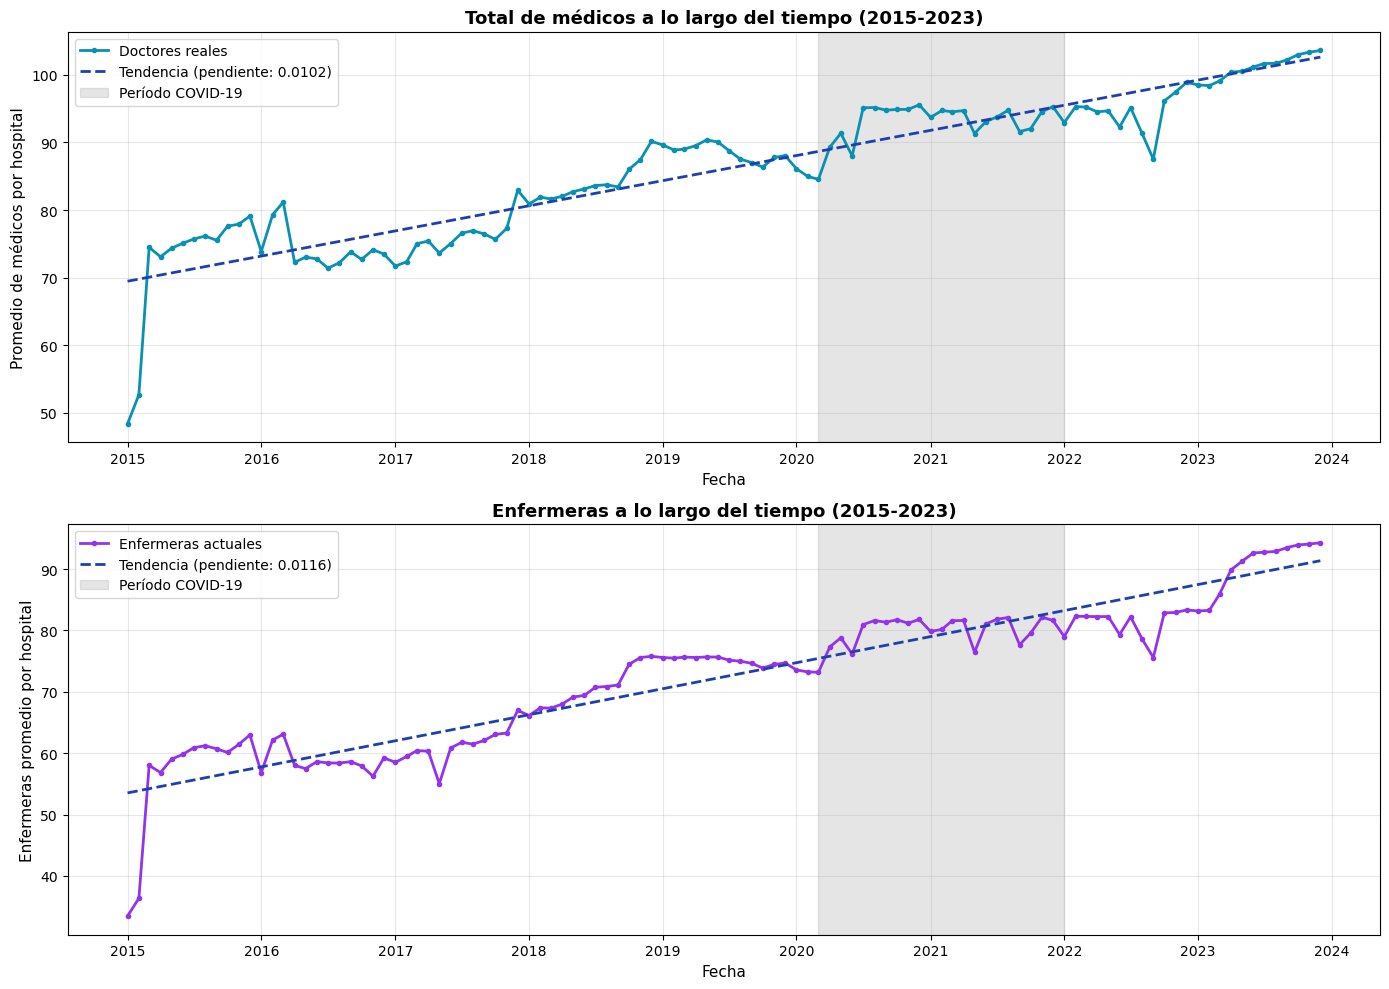

ANÁLISIS DE TENDENCIAS DE LA FUERZA LABORAL

DOCTORS:
  Trend slope: 0.010192 doctors per day
  Trend direction: INCREASING
  Overall mean: 86.06 doctors/hospital

NURSES:
  Trend slope: 0.011616 nurses per day
  Trend direction: INCREASING
  Overall mean: 72.46 nurses/hospital

Pre-COVID workforce:
  Doctors: 79.04
  Nurses: 64.59

Post-COVID workforce:
  Doctors: 97.73
  Nurses: 85.85


In [38]:
# Doctores
df_balanced['total_doctors'] = df_balanced['doctors'] + df_balanced['spec_doctors']

# Promedio de la fuerza laboral total
workforce_over_time = df_balanced.groupby('date').agg({
    'total_doctors': 'mean',
    'nurses': 'mean'
}).reset_index()

# Fecha 
workforce_over_time['date_numeric'] = (workforce_over_time['date'] - workforce_over_time['date'].min()).dt.days

# Lineas de tendencia
z_doctors = np.polyfit(workforce_over_time['date_numeric'], workforce_over_time['total_doctors'], 1)
z_nurses = np.polyfit(workforce_over_time['date_numeric'], workforce_over_time['nurses'], 1)
p_doctors = np.poly1d(z_doctors)
p_nurses = np.poly1d(z_nurses)
trend_doctors = p_doctors(workforce_over_time['date_numeric'])
trend_nurses = p_nurses(workforce_over_time['date_numeric'])

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Doctors plot
ax1.plot(workforce_over_time['date'], workforce_over_time['total_doctors'], 
         linewidth=2, color='#0891b2', marker='o', markersize=3, label='Doctores reales')
ax1.plot(workforce_over_time['date'], trend_doctors, 
         linewidth=2, color='#1e40af', linestyle='--', label=f'Tendencia (pendiente: {z_doctors[0]:.4f})')
ax1.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
            alpha=0.2, color='gray', label='Período COVID-19')
ax1.set_title('Total de médicos a lo largo del tiempo (2015-2023)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Promedio de médicos por hospital', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Nurses plot
ax2.plot(workforce_over_time['date'], workforce_over_time['nurses'], 
         linewidth=2, color='#9333ea', marker='o', markersize=3, label='Enfermeras actuales')
ax2.plot(workforce_over_time['date'], trend_nurses, 
         linewidth=2, color='#1e40af', linestyle='--', label=f'Tendencia (pendiente: {z_nurses[0]:.4f})')
ax2.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
            alpha=0.2, color='gray', label='Período COVID-19')
ax2.set_title('Enfermeras a lo largo del tiempo (2015-2023)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Enfermeras promedio por hospital', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Statistics
print("="*80)
print("ANÁLISIS DE TENDENCIAS DE LA FUERZA LABORAL")
print("="*80)
print(f"\nDOCTORS:")
print(f"  Trend slope: {z_doctors[0]:.6f} doctors per day")
print(f"  Trend direction: {'INCREASING' if z_doctors[0] > 0 else 'DECREASING'}")
print(f"  Overall mean: {df_balanced['total_doctors'].mean():.2f} doctors/hospital")

print(f"\nNURSES:")
print(f"  Trend slope: {z_nurses[0]:.6f} nurses per day")
print(f"  Trend direction: {'INCREASING' if z_nurses[0] > 0 else 'DECREASING'}")
print(f"  Overall mean: {df_balanced['nurses'].mean():.2f} nurses/hospital")

print(f"\nPre-COVID workforce:")
print(f"  Doctors: {df_balanced[df_balanced['date'] < '2020-03-01']['total_doctors'].mean():.2f}")
print(f"  Nurses: {df_balanced[df_balanced['date'] < '2020-03-01']['nurses'].mean():.2f}")

print(f"\nPost-COVID workforce:")
print(f"  Doctors: {df_balanced[df_balanced['date'] > '2021-12-31']['total_doctors'].mean():.2f}")
print(f"  Nurses: {df_balanced[df_balanced['date'] > '2021-12-31']['nurses'].mean():.2f}")

# Lead-Lag analysis

Mayor gasto en un mes [t] implica menor mortalidad en [t+1 .. n]? 


HOSPITAL_DISCHARGES:
  Spending (t) → Outcome (t):     r = 0.568
  Spending (t-1) → Outcome (t):   r = 0.568
  Spending (t-2) → Outcome (t):   r = 0.556
  Spending (t-3) → Outcome (t):   r = 0.563

MEDICAL_VISITS_FIRSTLEVEL:
  Spending (t) → Outcome (t):     r = 0.036
  Spending (t-1) → Outcome (t):   r = 0.043
  Spending (t-2) → Outcome (t):   r = 0.034
  Spending (t-3) → Outcome (t):   r = 0.033

MORTALITY_RATE:
  Spending (t) → Outcome (t):     r = 0.192
  Spending (t-1) → Outcome (t):   r = 0.198
  Spending (t-2) → Outcome (t):   r = 0.189
  Spending (t-3) → Outcome (t):   r = 0.190


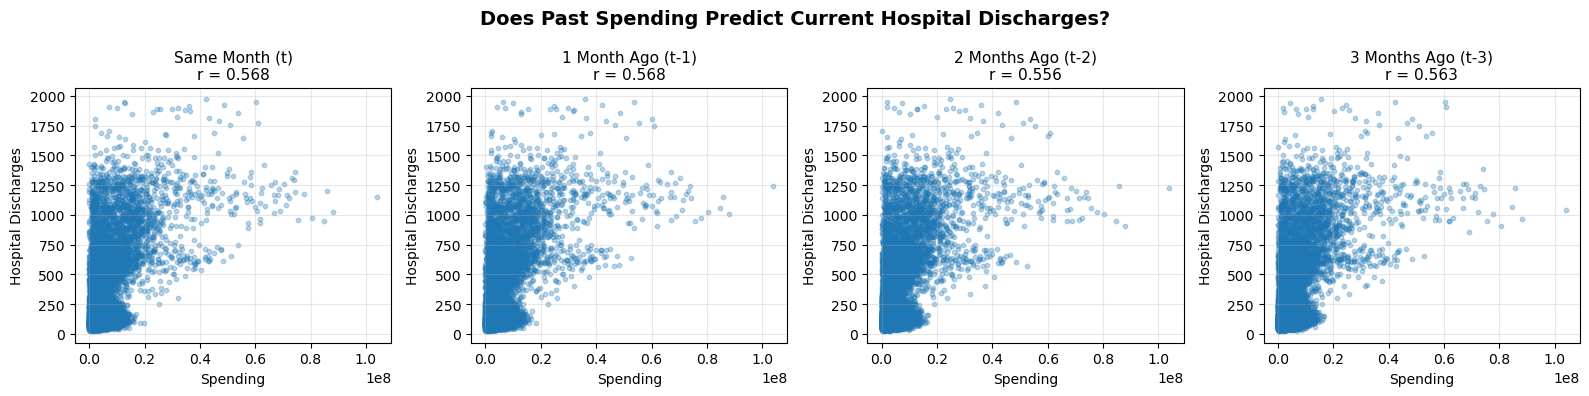

In [39]:
# Create lagged spending variables (spending from 1, 2, 3 months ago)
df_balanced = df_balanced.sort_values(['health_center_name', 'date'])

# Create lags by hospital
df_balanced['spending_lag1'] = df_balanced.groupby('health_center_name')['pagado_monthly'].shift(1)
df_balanced['spending_lag2'] = df_balanced.groupby('health_center_name')['pagado_monthly'].shift(2)
df_balanced['spending_lag3'] = df_balanced.groupby('health_center_name')['pagado_monthly'].shift(3)


outcomes = ['hospital_discharges', 'medical_visits_firstlevel', 'mortality_rate']

for outcome in outcomes:
    print(f"\n{outcome.upper()}:")
    
    # Current month correlation
    corr_t0 = df_balanced[['pagado_monthly', outcome]].corr().iloc[0, 1]
    print(f"  Spending (t) → Outcome (t):     r = {corr_t0:.3f}")
    
    # 1 month lag
    corr_t1 = df_balanced[['spending_lag1', outcome]].corr().iloc[0, 1]
    print(f"  Spending (t-1) → Outcome (t):   r = {corr_t1:.3f}")
    
    # 2 month lag
    corr_t2 = df_balanced[['spending_lag2', outcome]].corr().iloc[0, 1]
    print(f"  Spending (t-2) → Outcome (t):   r = {corr_t2:.3f}")
    
    # 3 month lag
    corr_t3 = df_balanced[['spending_lag3', outcome]].corr().iloc[0, 1]
    print(f"  Spending (t-3) → Outcome (t):   r = {corr_t3:.3f}")

# Visualize for hospital discharges
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Does Past Spending Predict Current Hospital Discharges?', fontsize=14, fontweight='bold')

lags = [
    ('pagado_monthly', 'Same Month (t)'),
    ('spending_lag1', '1 Month Ago (t-1)'),
    ('spending_lag2', '2 Months Ago (t-2)'),
    ('spending_lag3', '3 Months Ago (t-3)')
]

for idx, (lag_var, title) in enumerate(lags):
    mask = df_balanced[[lag_var, 'hospital_discharges']].notna().all(axis=1)
    axes[idx].scatter(df_balanced.loc[mask, lag_var], 
                     df_balanced.loc[mask, 'hospital_discharges'], 
                     alpha=0.3, s=10)
    
    corr = df_balanced[[lag_var, 'hospital_discharges']].corr().iloc[0, 1]
    axes[idx].set_title(f'{title}\nr = {corr:.3f}', fontsize=11)
    axes[idx].set_xlabel('Spending', fontsize=10)
    axes[idx].set_ylabel('Hospital Discharges', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
# Los hospitales que gastan más gestionan más egresos
# pero es probable que se trate de causas simultáneas y no causales
# los r-values no muestran mayor relación 